In [2]:
import pyzx as zx
import numpy as np


In [6]:
# Distillation circuit: Qiskit qc.cx(ctrl, tgt) -> PyZX c.add_gate('CNOT', ctrl, tgt)
n_qubits = 16
c = zx.Circuit(n_qubits)

# Layer 1
c.add_gate('CNOT', 1, 9)
c.add_gate('CNOT', 2, 10)
c.add_gate('CNOT', 4, 12)
# Layer 2
c.add_gate('CNOT', 0, 4)
c.add_gate('CNOT', 1, 5)
c.add_gate('CNOT', 2, 6)
c.add_gate('CNOT', 8, 12)
c.add_gate('CNOT', 9, 13)
c.add_gate('CNOT', 10, 14)
# Layer 3
c.add_gate('CNOT', 0, 2)
c.add_gate('CNOT', 1, 3)
c.add_gate('CNOT', 4, 6)
c.add_gate('CNOT', 5, 7)
c.add_gate('CNOT', 8, 10)
c.add_gate('CNOT', 9, 11)
c.add_gate('CNOT', 12, 14)
c.add_gate('CNOT', 13, 15)
# Layer 4
c.add_gate('CNOT', 0, 1)
c.add_gate('CNOT', 2, 3)
c.add_gate('CNOT', 4, 5)
c.add_gate('CNOT', 6, 7)
c.add_gate('CNOT', 8, 9)
c.add_gate('CNOT', 10, 11)
c.add_gate('CNOT', 12, 13)
c.add_gate('CNOT', 14, 15)

# Convert to ZX diagram and draw
g = c.to_basic_gates().to_graph()
# zx.draw(g)
# Simplify the ZX diagram and display the result
zx.simplify.full_reduce(g)
zx.draw(g)



In [ ]:
g_s_gate = 

In [15]:
# rotate,8,i,z,z,y,i,z,y,y,,
sequence  = ['i', 'z', 'z', 'y', 'i', 'z', 'y', 'y']

# y count calculation 
y_count = 0
for i in sequence:
    if i == 'y':
        y_count += 1
if y_count%2 != 0:
    sequence.append('rs')

sequence.append('anc')

print(sequence)

['i', 'z', 'z', 'y', 'i', 'z', 'y', 'y', 'rs', 'anc']


In [44]:
cnot_edges_zy = []
cnot_edges_xy = []
# add edges between all the 'z' vertices an ancilla and 'y' and ancilla
for i in range(len(sequence)):
    if sequence[i] == 'z' or sequence[i] == 'y' or sequence[i] == 'rs':
        cnot_edges_zy.append((i, len(sequence)-1))
    if sequence[i] == 'x' or sequence[i] == 'y' or sequence[i] == 'rs':
        cnot_edges_xy.append((len(sequence)-1, i))


print(cnot_edges_zy)
print(cnot_edges_xy)


[(1, 9), (2, 9), (3, 9), (5, 9), (6, 9), (7, 9), (8, 9)]
[(9, 3), (9, 6), (9, 7), (9, 8)]


In [ ]:
# one node should not be connected by more that 4 edges     
c = zx.Circuit(len(sequence))
for i in range(len(cnot_edges_zy)):
    c.add_gate('CNOT', cnot_edges_zy[i][0], cnot_edges_zy[i][1])
c.add_gate('H', len(sequence)-1)
for i in range(len(cnot_edges_xy)):
    c.add_gate('CNOT', cnot_edges_xy[i][0], cnot_edges_xy[i][1])
zx.draw(c)
g = c.to_basic_gates().to_graph()

In [ ]:
# distillation circuit  
n_qubits = 16
c = zx.Circuit(n_qubits)

qc.cx(1, 9)
    qc.cx(2, 10)
    qc.cx(4, 12)
    ##
    qc.cx(0, 4)
    qc.cx(1, 5)
    qc.cx(2, 6)

    qc.cx(8, 12)
    qc.cx(9, 13)
    qc.cx(10, 14)
    ##
    qc.cx(0, 2)
    qc.cx(1, 3)
    qc.cx(4, 6)
    qc.cx(5, 7)
    qc.cx(8, 10)
    qc.cx(9, 11)
    qc.cx(12, 14)
    qc.cx(13, 15)
    ##
    qc.cx(0, 1)
    qc.cx(2, 3)
    qc.cx(4, 5)
    qc.cx(6, 7)
    qc.cx(8, 9)
    qc.cx(10, 11)
    qc.cx(12, 13)
    qc.cx(14, 15)



In [48]:
ancilla_nodes_left  = np.floor((len(cnot_edges_zy) + 1)/2)
ancilla_nodes_right = np.floor((len(cnot_edges_xy) + 1)/2)
qubit_nodes_left = len(cnot_edges_zy)
qubit_nodes_right = len(cnot_edges_xy)
connector_node = 1
total_nodes = ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left + qubit_nodes_right + connector_node
print(total_nodes)


18.0


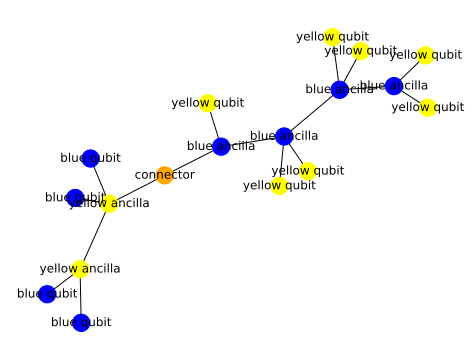

In [104]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph()
G.add_nodes_from(range(int(total_nodes)))



# add labels to the ancilla nodes left
for i in range(int(ancilla_nodes_left)):
    G.nodes[i]['label'] = 'blue ancilla'
    G.nodes[i]['color'] = 'blue'

# add labels to the ancilla nodes right
for i in range(int(ancilla_nodes_left), int(ancilla_nodes_left + ancilla_nodes_right)):
    G.nodes[i]['label'] = 'yellow ancilla'
    G.nodes[i]['color'] = 'yellow'

# add labels to the qubit nodes left
for i in range(int(ancilla_nodes_left + ancilla_nodes_right), int(ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left)):
    G.nodes[i]['label'] = 'yellow qubit'
    G.nodes[i]['color'] = 'yellow'
    G.nodes[i]['name'] = 'q' + str(cnot_edges_zy[i-int(ancilla_nodes_left + ancilla_nodes_right)][0])

    

# add labels to the qubit nodes right
for i in range(int(ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left), int(ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left + qubit_nodes_right)):
    G.nodes[i]['label'] = 'blue qubit'
    G.nodes[i]['color'] = 'blue'
    G.nodes[i]['name'] = 'q' + str(cnot_edges_xy[i-int(ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left)][1])
# add labels to the connector node and color it orange
connector_idx = int(ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left + qubit_nodes_right)
G.nodes[connector_idx]['label'] = 'connector'
G.nodes[connector_idx]['color'] = 'orange'  # Explicitly set orange color

# Connect blue ancillas to each other
for i in range(int(ancilla_nodes_left) - 1):
    G.add_edge(i, i+1)

# Connect last blue ancilla to connector
G.add_edge(int(ancilla_nodes_left) - 1, connector_idx, color='red')


# Connect yellow ancillas to each other and finally to the connector
start_yellow = int(ancilla_nodes_left)
end_yellow = int(ancilla_nodes_left + ancilla_nodes_right)
for i in range(start_yellow, end_yellow - 1):
    G.add_edge(i, i+1)
if ancilla_nodes_right > 0:
    G.add_edge(end_yellow - 1, connector_idx)

# Connect each left ancilla node to 2 yellow qubit nodes (one-to-two mapping)
yellow_qubit_start = int(ancilla_nodes_left + ancilla_nodes_right)
for i in range(int(ancilla_nodes_left)):
    yq1 = yellow_qubit_start + 2 * i
    yq2 = yellow_qubit_start + 2 * i + 1
    # Always connect to first yellow qubit in the pair
    if yq1 < yellow_qubit_start + int(qubit_nodes_left):
        G.add_edge(i, yq1)
    # Only connect to second yellow qubit if it exists
    if yq2 < yellow_qubit_start + int(qubit_nodes_left):
        G.add_edge(i, yq2)

# Connect each right ancilla node to 2 blue qubit nodes (one-to-two mapping)
blue_qubit_start = int(ancilla_nodes_left + ancilla_nodes_right + qubit_nodes_left)
for i in range(int(ancilla_nodes_right)):
    bq1 = blue_qubit_start + 2 * i
    bq2 = blue_qubit_start + 2 * i + 1
    # Always connect to first blue qubit in the pair
    if bq1 < blue_qubit_start + int(qubit_nodes_right):
        G.add_edge(i + int(ancilla_nodes_left), bq1)
    # Only connect to second blue qubit if it exists
    if bq2 < blue_qubit_start + int(qubit_nodes_right):
        G.add_edge(i + int(ancilla_nodes_left), bq2)



# Use node colors for drawing
labels = nx.get_node_attributes(G, 'label')
node_colors = [G.nodes[n].get('color', 'gray') for n in G.nodes]

nx.draw(G, labels=labels, with_labels=True, node_color=node_colors)
plt.show()






In [100]:
# print G nodes
print(G.nodes)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [ ]:

class Hexagon:
    def __init__(self, index):
        self.index = index
        self.ports = {d: None for d in ['up', 'down', 'north', 'south', 'east', 'west']}

    def connect(self, direction, neighbor_index):
        self.ports[direction] = neighbor_index

direction = ['up', 'down', 'north', 'south', 'east', 'west']
sequence_i_want = []
for i in G.nodes:
    n_neighbours = list(G.neighbors(i))
    # print(i, n_neighbours)
    hexagon = Hexagon(i) # i is the active volume index
    name = G.nodes[i]['name'] if 'name' in G.nodes[i] else None
    if len(n_neighbours) == 1 and i <= len(G.nodes)//2:
        hexagon.connect('up', name)
        hexagon.connect('down', name)
        hexagon.connect('south', n_neighbours[0])
    elif len(n_neighbours) == 1 and i > len(G.nodes)//2:
        hexagon.connect('up', name)
        hexagon.connect('down', name)
        hexagon.connect('north', n_neighbours[0])
    elif len(n_neighbours) == 2 and i < len(G.nodes)//2:
        hexagon.connect('north', n_neighbours[0])
        hexagon.connect('south', n_neighbours[1])
    elif len(n_neighbours) == 2 and i > len(G.nodes)//2:
        hexagon.connect('south', n_neighbours[0])
        hexagon.connect('north', n_neighbours[1])
    elif len(n_neighbours) == 3 and i < len(G.nodes)//2:
        hexagon.connect('east', n_neighbours[0])
        hexagon.connect('north', n_neighbours[1])
        hexagon.connect('south', n_neighbours[2])
    elif len(n_neighbours) == 3 and i > len(G.nodes)//2:
        hexagon.connect('west', n_neighbours[0])
        hexagon.connect('south', n_neighbours[1])
        hexagon.connect('north', n_neighbours[2])
    elif len(n_neighbours) == 4 and i < len(G.nodes)//2:
        hexagon.connect('west', n_neighbours[0])
        hexagon.connect('east', n_neighbours[1])
        hexagon.connect('north', n_neighbours[2])
        hexagon.connect('south', n_neighbours[3])
    elif len(n_neighbours) == 4 and i > len(G.nodes)//2:
        hexagon.connect('east', n_neighbours[0])
        hexagon.connect('west', n_neighbours[1])
        hexagon.connect('south', n_neighbours[2])
        hexagon.connect('north', n_neighbours[3])
    sequence_i_want.append(hexagon)
    if i == len(G.nodes)//2 + 1:
        hexagon.connect('up', name)


# save this in csv file

 # if the node name in 'up' appears twice, then replace the down with b0 in the first one and replace the up with b1 in the second one

# Build a map of up node names to all hexagons referencing that 'up'
up_map = {}
for hexagon in sequence_i_want:
    up_val = hexagon.ports.get('up')
    if up_val is not None:
        up_map.setdefault(up_val, []).append(hexagon)

# For each up value that appears twice, apply the replacements as specified
for up_val, hexagons in up_map.items():
    if up_val is not None and len(hexagons) == 2:
        # In the first hexagon, replace 'down' with 'b0' if present
        if 'down' in hexagons[0].ports and hexagons[0].ports['down'] == up_val:
            hexagons[0].ports['down'] = 'b' + str(hexagons[0].index)
        # In the second hexagon, replace 'up' with 'b1' if present
        if 'up' in hexagons[1].ports and hexagons[1].ports['up'] == up_val:
            hexagons[1].ports['up'] = 'b' + str(hexagons[0].index)

for i in sequence_i_want:
    print(i.index, i.ports)

import csv

# Create a list to store the data
data = []

for i in sequence_i_want:
    data.append([i.index, i.ports])


# Write the data to a CSV file
with open('hexagon_data.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerows(data)







0 {'up': None, 'down': None, 'north': 6, 'south': 7, 'east': 1, 'west': None}
1 {'up': None, 'down': None, 'north': 8, 'south': 9, 'east': 2, 'west': 0}
2 {'up': None, 'down': None, 'north': 10, 'south': 11, 'east': 3, 'west': 1}
3 {'up': None, 'down': None, 'north': 17, 'south': 12, 'east': 2, 'west': None}
4 {'up': None, 'down': None, 'north': 13, 'south': 14, 'east': 5, 'west': None}
5 {'up': None, 'down': None, 'north': 15, 'south': 16, 'east': 17, 'west': 4}
6 {'up': 'q1', 'down': 'q1', 'north': None, 'south': 0, 'east': None, 'west': None}
7 {'up': 'q2', 'down': 'q2', 'north': None, 'south': 0, 'east': None, 'west': None}
8 {'up': 'q3', 'down': 'q3', 'north': None, 'south': 1, 'east': None, 'west': None}
9 {'up': 'q5', 'down': 'q5', 'north': None, 'south': 1, 'east': None, 'west': None}
10 {'up': 'q6', 'down': 'q6', 'north': 2, 'south': None, 'east': None, 'west': None}
11 {'up': 'q7', 'down': 'q7', 'north': 2, 'south': None, 'east': None, 'west': None}
12 {'up': 'q8', 'down': 'q

In [31]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

n = 4  # Number of core (blue) nodes
core_nodes = list(range())  # Blue nodes: 0 to 3
yellow_id = n  # Start yellow node IDs after blue nodes

# Keep track of node attributes
node_attrs = {}

# Add core (blue) nodes
for i in core_nodes:
    G.add_node(i)
    node_attrs[i] = {'color': 'blue'}

# Add connections
for i in core_nodes:
    # Add 2 yellow neighbors per core node
    for _ in range(2):
        yellow_node = yellow_id
        G.add_node(yellow_node)
        node_attrs[yellow_node] = {'color': 'orange'}
        G.add_edge(i, yellow_node)
        yellow_id += 1

    # Add internal edge(s) between adjacent core nodes
    if i < n - 1:
        G.add_edge(i, i + 1)

# Apply attributes
colors = [node_attrs[n]['color'] for n in G.nodes]

# Layout and drawing
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=700)
plt.show()


TypeError: range expected 1 argument, got 0